In [1]:
import os
from dotenv import find_dotenv, load_dotenv
from typing import Annotated
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel, Field
from typing_extensions import TypedDict
from langchain_openai import ChatOpenAI

from langchain.chat_models import init_chat_model
# 加载 .env 文件中的环境变量
load_dotenv()

api_key = os.getenv("DASHSCOPE_API_KEY")
base_url = os.getenv("DASHSCOPE_BASE_URL")



In [2]:
llm = ChatOpenAI(
    model = "qwen3.5-35b-a3b",
    api_key=api_key,
    base_url=base_url,
    extra_body={"enable_thinking":False}
)


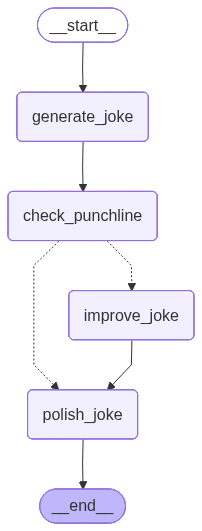

In [ ]:
# ==========================================
# 3. 定义图状态
# ==========================================
class State(TypedDict):
    joke: str
    topic: str
    punchline: str
    needs_improvement: bool

# ==========================================
# 4. 定义用于评估笑话的结构化输出模型
# ==========================================
class PunchlineEvaluation(BaseModel):
    needs_improvement: bool = Field(
        description="判断笑话是否需要改进。如果笑点明显或平庸，返回 true。"
    )

# 使用结构化输出增强 LLM
evaluator = llm.with_structured_output(PunchlineEvaluation)

# ==========================================
# 5. 定义节点
# ==========================================
def generate_joke(state: State):
    """生成一个关于给定主题的笑话"""
    joke = llm.invoke(f"写一个关于 {state['topic']} 的笑话")
    return {"joke": joke.content}

def check_punchline(state: State):
    """检查笑话是否需要改进"""
    evaluation = evaluator.invoke(
        f"评估这个笑话的笑点：{state['joke']}。请仅返回 json 对象，包含键 needs_improvement（布尔值），不要输出其他文字。"
    )
    return {"needs_improvement": evaluation.needs_improvement}

def improve_joke(state: State):
    """改进笑话"""
    improved_joke = llm.invoke(f"改进这个笑话，使其更有趣: {state['joke']}")
    return {"joke": improved_joke.content}

def polish_joke(state: State):
    """润色笑话，确保质量"""
    polished_joke = llm.invoke(f"润色这个笑话，使其更加完美: {state['joke']}")
    return {"joke": polished_joke.content}

# ==========================================
# 6. 定义条件边函数
# ==========================================
def should_improve_joke(state: State):
    """根据笑话是否需要改进来决定路由"""
    if state["needs_improvement"]:
        return "improve_joke"
    else:
        return "polish_joke"

# ==========================================
# 7. 构建工作流
# ==========================================
workflow_builder = StateGraph(State)

# 添加节点
workflow_builder.add_node("generate_joke", generate_joke)
workflow_builder.add_node("check_punchline", check_punchline)
workflow_builder.add_node("improve_joke", improve_joke)
workflow_builder.add_node("polish_joke", polish_joke)

# 添加边来连接节点
workflow_builder.add_edge(START, "generate_joke")
workflow_builder.add_edge("generate_joke", "check_punchline")
workflow_builder.add_conditional_edges(
    "check_punchline",
    should_improve_joke,
    {  # 由 should_improve_joke 返回的值 : 要访问的下一个节点的名称
        "improve_joke": "improve_joke",
        "polish_joke": "polish_joke"
    }
)
workflow_builder.add_edge("improve_joke", "polish_joke")
workflow_builder.add_edge("polish_joke", END)

# 编译工作流
workflow = workflow_builder.compile()

# ==========================================
# 8. 显示与调用
# ==========================================
try:
    from IPython.display import display, Image
    display(Image(workflow.get_graph().draw_mermaid_png()))
except Exception:
    print("无法显示工作流图片")

# 调用工作流
state = workflow.invoke({"topic": "编程"})
print(state["joke"])

In [ ]:
class State(TypedDict):
    joke: str
    topic: str
    punchline: str
    needs_improvement: bool



In [ ]:




model = init_chat_model(
    model="qwen3.5-35b-a3b",
    model_provider="openai",
    api_key=api_key,
    base_url=base_url,
    # 尝试显式关闭思考模式
    extra_body={"enable_thinking": False} 
)